In [25]:
import pandas as pd
import os

In [26]:
file_path = r'C:\Users\kaila\Documents\TCC\data\cientista_cp.xlsx'

In [27]:
# Load dataset directly
df = pd.read_excel(file_path, engine='openpyxl')

In [28]:
df.head()

,MUNICIPIO,PROGRAMA,ANO,cadastros,beneficiarios,valor,total_pcp,total_pcp_corrigido,valor_total,cd_mun
0,ABREU E LIMA,PESCA ARTESANAL,2025,101,101,94785.2,94785.2,94785.2,0,2600054
1,ABREU E LIMA,ZONA CANAVIEIRA,2025,1,1,1865.4,1865.4,1865.4,0,2600054
2,ABREU E LIMA,PESCA ARTESANAL,2021,78,77,14790.0,59160.0,59160.0,59160,2600054
3,ABREU E LIMA,PESCA ARTESANAL,2022,95,93,21411.8,85647.2,85647.2,85647,2600054
4,ABREU E LIMA,PESCA ARTESANAL,2023,91,90,18195.0,72780.0,72780.0,72780,2600054


In [31]:
df['MUNICIPIO'].value_counts()

MUNICIPIO
BARREIROS                  10
GAMELEIRA                  10
GOIANA                     10
CABO DE SANTO AGOSTINHO    10
IGARASSU                   10
                           ..
PESQUEIRA                   1
SALGADINHO                  1
POCAO                       1
SANTA MARIA DO CAMBUCA      1
SURUBIM                     1
Name: count, Length: 101, dtype: int64

In [33]:
df['MUNICIPIO'].unique().size

101

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MUNICIPIO            517 non-null    object 
 1   PROGRAMA             517 non-null    object 
 2   ANO                  517 non-null    int64  
 3   cadastros            517 non-null    int64  
 4   beneficiarios        517 non-null    int64  
 5   valor                517 non-null    float64
 6   total_pcp            517 non-null    float64
 7   total_pcp_corrigido  517 non-null    float64
 8   valor_total          517 non-null    int64  
 9   cd_mun               517 non-null    int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 40.5+ KB


#### Data dictionary (?)
 | Column               | Description                                              |
 |----------------------|----------------------------------------------------------|
 | MUNICIPIO            | Name of the municipality in Pernambuco                   |
 | PROGRAMA             | Program segment (Fishing, Sugarcane, or Fruit)           |
 | ANO                  | Reference year (2021-2025)                                |
 | cadastros            | Number of registrations performed                        |
 | beneficiarios        | Number of effective beneficiaries (Target Variable)       |
 | valor                | Base installment or individual value                     |
 | total_pcp            | Total annual amount paid (Raw values)                    |
 | total_pcp_corrigido  | Total annual amount paid (Inflation/Correction adjusted) |
 | valor_total          | Final accounting total for the period                    |
 | cd_mun               | IBGE municipality code                                   |

In [5]:
# Data cleaning and type conversion
# Ensure numeric consistency for time series analysis
df['beneficiarios'] = pd.to_numeric(df['beneficiarios'], errors='coerce').fillna(0)
df['ANO'] = pd.to_numeric(df['ANO'], errors='coerce').fillna(0).astype(int)

In [6]:
# 1. Program summary
print("Number of Municipalities per Program")
df.groupby('PROGRAMA')['MUNICIPIO'].nunique()


Number of Municipalities per Program


PROGRAMA
FRUTICULTURA IRRIGADA    14
PESCA ARTESANAL          64
ZONA CANAVIEIRA          60
Name: MUNICIPIO, dtype: int64

In [7]:
# 2. Yearly Total (State Level Trend)
# This provides the 'global' view for ARIMA/ETS initial assessment
print("Yearly Beneficiaries Evolution (Total)")
global_evolution = df.groupby('ANO')['beneficiarios'].sum()
global_evolution

Yearly Beneficiaries Evolution (Total)


ANO
2021    37470
2022    28035
2023    21675
2024    20698
2025    20070
Name: beneficiarios, dtype: int64

In [8]:
# 3. Data Integrity Check (Missing years per group)
pivot_table = df.pivot_table(values='beneficiarios', 
                             index=['MUNICIPIO', 'PROGRAMA'], 
                             columns='ANO', 
                             aggfunc='sum')

print("Count of missing data points (NaN) per year")
pivot_table.isnull().sum()

Count of missing data points (NaN) per year


ANO
2021    45
2022    35
2023    34
2024    42
2025    18
dtype: int64

Estatística Descritiva
         cadastros  beneficiarios         valor     total_pcp  \
count   517.000000     517.000000  5.170000e+02  5.170000e+02   
mean    259.651838     247.481625  1.107150e+05  2.765101e+05   
std     467.691542     445.590817  2.792033e+05  4.906494e+05   
min       1.000000       0.000000  1.000000e+02  4.000000e+02   
25%      18.000000      15.000000  5.230800e+03  1.642320e+04   
50%     112.000000     107.000000  3.441380e+04  1.168470e+05   
75%     340.000000     329.000000  1.154839e+05  3.531672e+05   
max    5205.000000    4942.000000  4.863455e+06  4.863455e+06   

       total_pcp_corrigido   valor_total  
count         5.170000e+02  5.170000e+02  
mean          2.889379e+05  2.210601e+05  
std           5.150943e+05  4.396419e+05  
min           4.000000e+02  0.000000e+00  
25%           1.807790e+04  1.200000e+03  
50%           1.273328e+05  6.140200e+04  
75%           3.548248e+05  2.713560e+05  
max           5.040535e+06  4.719894e+06  

Evo

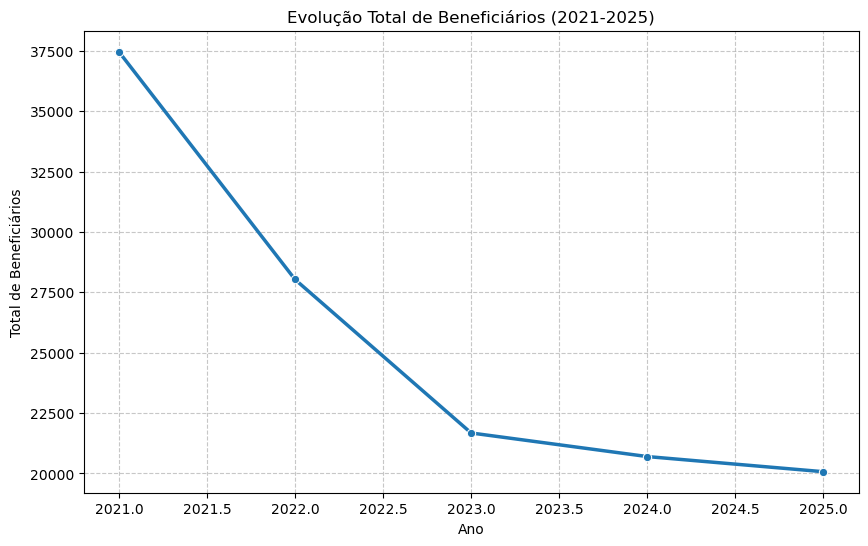


Evolução de Beneficiários por Programa
     ANO               PROGRAMA  beneficiarios
0   2021  FRUTICULTURA IRRIGADA           6092
1   2021        PESCA ARTESANAL           4254
2   2021        ZONA CANAVIEIRA          27124
3   2022  FRUTICULTURA IRRIGADA           4548
4   2022        PESCA ARTESANAL           6692
5   2022        ZONA CANAVIEIRA          16795
6   2023  FRUTICULTURA IRRIGADA           4072
7   2023        PESCA ARTESANAL           6049
8   2023        ZONA CANAVIEIRA          11554
9   2024  FRUTICULTURA IRRIGADA           4570
10  2024        PESCA ARTESANAL           5567
11  2024        ZONA CANAVIEIRA          10561
12  2025  FRUTICULTURA IRRIGADA           4203
13  2025        PESCA ARTESANAL           5923
14  2025        ZONA CANAVIEIRA           9944


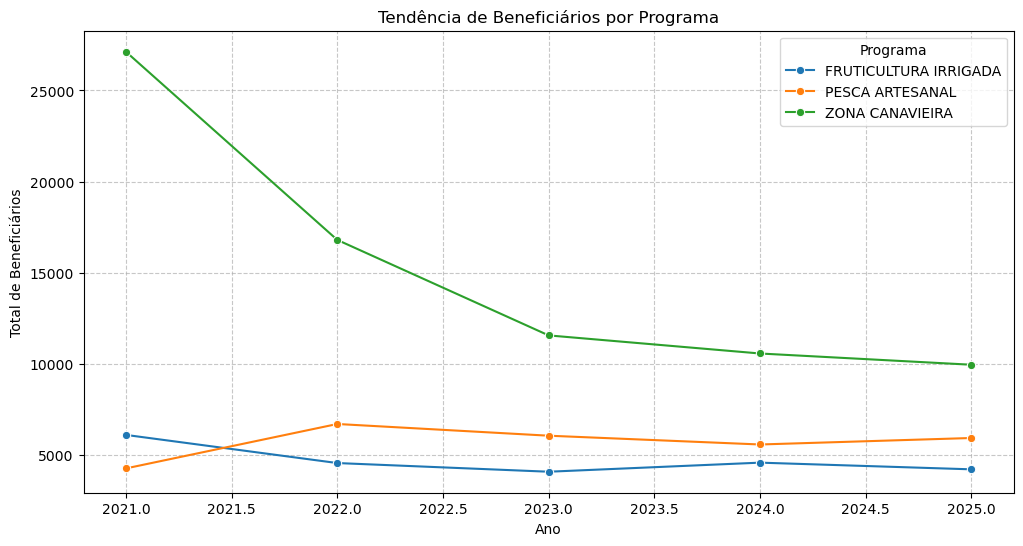


Matriz de Correlação
                     cadastros  beneficiarios  total_pcp_corrigido
cadastros             1.000000       0.998721             0.963339
beneficiarios         0.998721       1.000000             0.961553
total_pcp_corrigido   0.963339       0.961553             1.000000


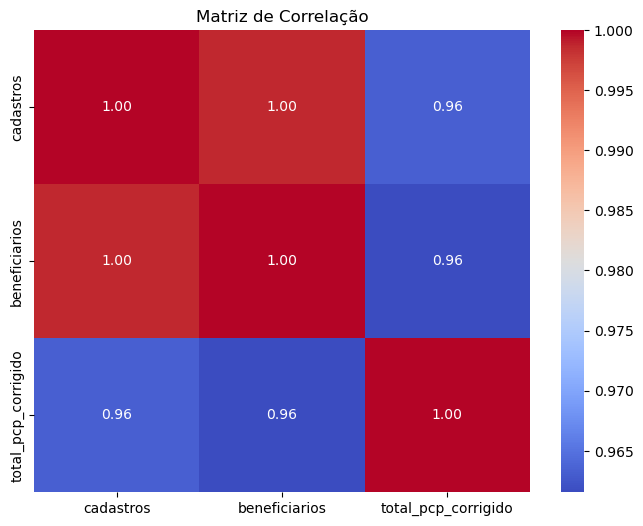

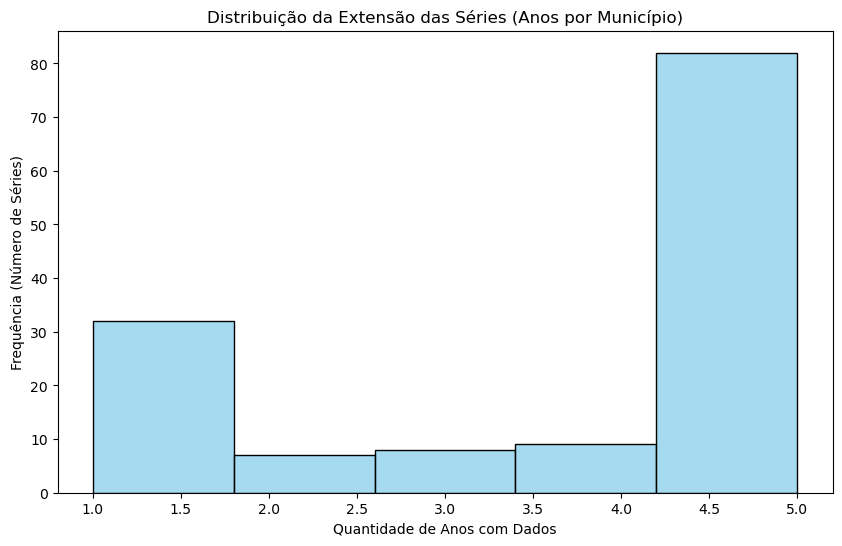

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define absolute path
file_path = r'C:\Users\kaila\Documents\TCC\data\cientista_cp.xlsx'

# Load dataset directly
df = pd.read_excel(file_path, engine='openpyxl')

# Data cleaning and type conversion
# Ensuring numeric consistency for analysis
cols_to_fix = ['cadastros', 'beneficiarios', 'valor', 'total_pcp', 'total_pcp_corrigido', 'valor_total']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df['ANO'] = pd.to_numeric(df['ANO'], errors='coerce').fillna(0).astype(int)

# 1. Descriptive Statistics
# Summary of the numerical variables for the TCC methodology
print("Estatística Descritiva")
print(df[cols_to_fix].describe())

# 2. Yearly Total (State Level Trend)
# Grouping data to see the overall decline of the program
yearly_total = df.groupby('ANO')['beneficiarios'].sum().reset_index()
print("\nEvolução Anual de Beneficiários (Total)")
print(yearly_total)

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_total, x='ANO', y='beneficiarios', marker='o', linewidth=2.5)
plt.title('Evolução Total de Beneficiários (2021-2025)')
plt.xlabel('Ano')
plt.ylabel('Total de Beneficiários')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Evolution by Program
# Comparing the trends across different segments (Sugarcane, Fishing, Fruit)
yearly_program = df.groupby(['ANO', 'PROGRAMA'])['beneficiarios'].sum().reset_index()
print("\nEvolução de Beneficiários por Programa")
print(yearly_program)

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_program, x='ANO', y='beneficiarios', hue='PROGRAMA', marker='o')
plt.title('Tendência de Beneficiários por Programa')
plt.xlabel('Ano')
plt.ylabel('Total de Beneficiários')
plt.legend(title='Programa')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Correlation Analysis
# Measuring the strength of the relationship between variables
corr = df[['cadastros', 'beneficiarios', 'total_pcp_corrigido']].corr()
print("\nMatriz de Correlação")
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

# 5. Data Density (Short Time Series Diagnostic)
# Visualizing how many points each series has for model validation
density = df.groupby(['MUNICIPIO', 'PROGRAMA'])['ANO'].nunique().reset_index()

plt.figure(figsize=(10, 6))
sns.histplot(density['ANO'], bins=5, kde=False, color='skyblue')
plt.title('Distribuição da Extensão das Séries (Anos por Município)')
plt.xlabel('Quantidade de Anos com Dados')
plt.ylabel('Frequência (Número de Séries)')
plt.show()

Evolução Anual - Setor Canavieiro
    ANO  cadastros  beneficiarios
0  2021      29716          27124
1  2022      17010          16795
2  2023      11797          11554
3  2024      11041          10561
4  2025      10200           9944


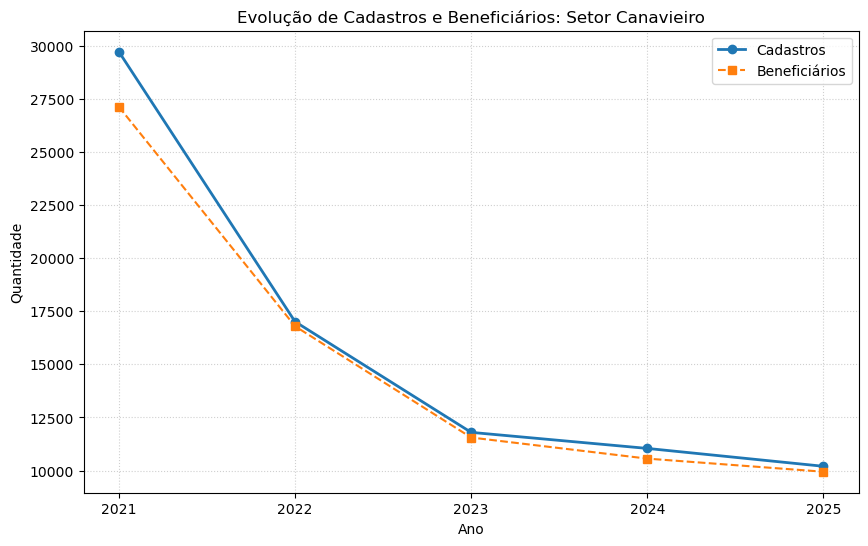

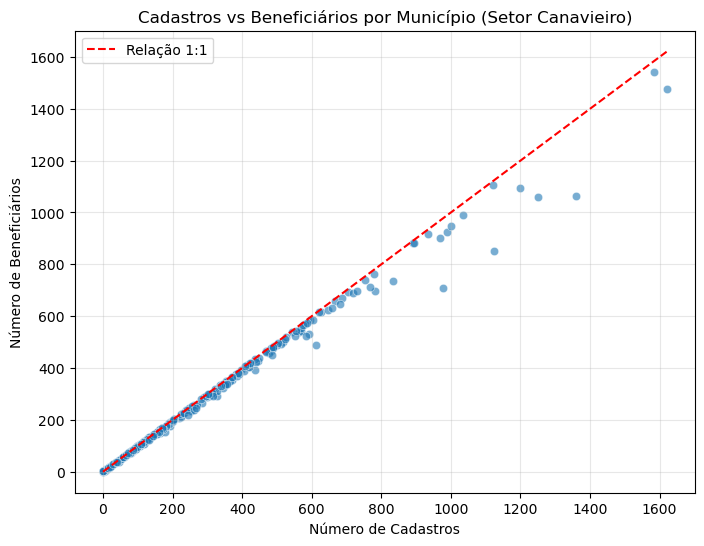

In [10]:

# Cleaning numeric columns
cols = ['cadastros', 'beneficiarios']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df['ANO'] = df['ANO'].astype(int)

# Filter for Sugarcane Sector
df_cana = df[df['PROGRAMA'] == 'ZONA CANAVIEIRA']

# Yearly aggregation for the sector
cana_yearly = df_cana.groupby('ANO')[['cadastros', 'beneficiarios']].sum().reset_index()

print("Evolução Anual - Setor Canavieiro")
print(cana_yearly)

# Plot 1: Evolution over time
plt.figure(figsize=(10, 6))
plt.plot(cana_yearly['ANO'], cana_yearly['cadastros'], marker='o', label='Cadastros', linewidth=2)
plt.plot(cana_yearly['ANO'], cana_yearly['beneficiarios'], marker='s', label='Beneficiários', linestyle='--')
plt.title('Evolução de Cadastros e Beneficiários: Setor Canavieiro')
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.xticks(cana_yearly['ANO'])
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Plot 2: Scatter Plot (Relationship at municipality level)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cana, x='cadastros', y='beneficiarios', alpha=0.6)
# Reference line 1:1
max_val = max(df_cana['cadastros'].max(), df_cana['beneficiarios'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Relação 1:1')
plt.title('Cadastros vs Beneficiários por Município (Setor Canavieiro)')
plt.xlabel('Número de Cadastros')
plt.ylabel('Número de Beneficiários')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

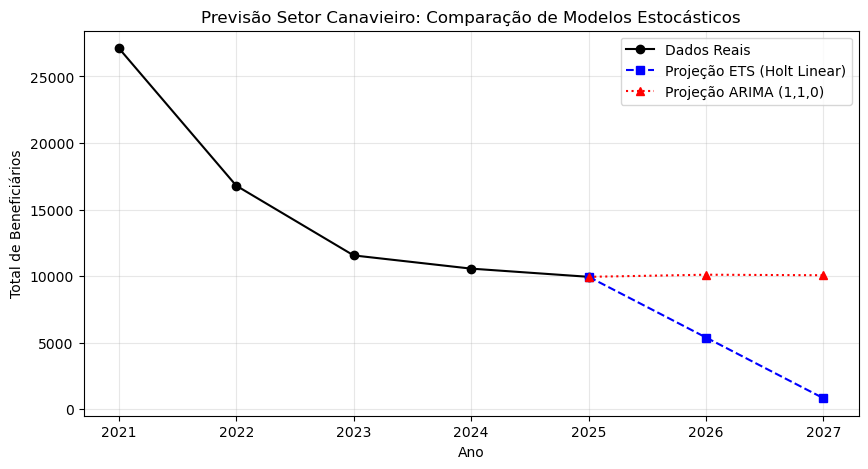

Previsão ETS para 2026: 5382 beneficiários
Previsão ARIMA para 2026: 10103 beneficiários


In [13]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 1. Preparação dos dados com Índice de Tempo Oficial
series_cana = df[df['PROGRAMA'] == 'ZONA CANAVIEIRA'].groupby('ANO')['beneficiarios'].sum()

# Transformando o índice em datetime e definindo frequência anual (YS = Year Start)
series_cana.index = pd.to_datetime(series_cana.index, format='%Y')
series_cana = series_cana.asfreq('YS')

# 2. Modelo ETS (Suavização Exponencial)
# Usamos 'add' para tendência. O parâmetro initialization_method evita avisos de otimização.
model_ets = ExponentialSmoothing(series_cana, trend='add', seasonal=None, initialization_method="estimated").fit()
forecast_ets = model_ets.forecast(2) 

# 3. Modelo ARIMA (1,1,0)
# Um modelo simples para evitar overfitting em séries curtas
model_arima = ARIMA(series_cana, order=(1, 1, 0)).fit()
forecast_arima = model_arima.forecast(2)

# 4. Visualização dos Resultados
plt.figure(figsize=(10, 5))

# Dados Reais
plt.plot(series_cana.index, series_cana.values, label='Dados Reais', marker='o', color='black')

# Projeção ETS
# Unimos o último ponto real com a previsão para continuidade visual
x_forecast = [series_cana.index[-1]] + list(forecast_ets.index)
y_ets = [series_cana.values[-1]] + list(forecast_ets.values)
plt.plot(x_forecast, y_ets, label='Projeção ETS (Holt Linear)', linestyle='--', marker='s', color='blue')

# Projeção ARIMA
y_arima = [series_cana.values[-1]] + list(forecast_arima.values)
plt.plot(x_forecast, y_arima, label='Projeção ARIMA (1,1,0)', linestyle=':', marker='^', color='red')

plt.title('Previsão Setor Canavieiro: Comparação de Modelos Estocásticos')
plt.xlabel('Ano')
plt.ylabel('Total de Beneficiários')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Acesso correto aos valores para o print
val_2026_ets = forecast_ets['2026-01-01']
val_2026_arima = forecast_arima['2026-01-01']

print(f"Previsão ETS para 2026: {val_2026_ets:.0f} beneficiários")
print(f"Previsão ARIMA para 2026: {val_2026_arima:.0f} beneficiários")

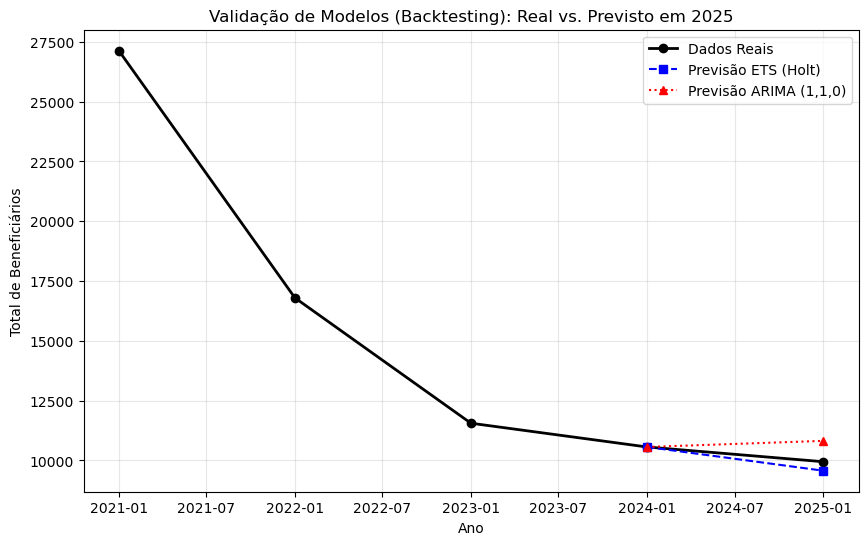

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# 1. Data Preparation
series_cana = df[df['PROGRAMA'] == 'ZONA CANAVIEIRA'].groupby('ANO')['beneficiarios'].sum()
series_cana.index = pd.to_datetime(series_cana.index, format='%Y')
series_cana = series_cana.asfreq('YS')

# 2. Training (2021-2024) and Forecasting 2025
train = series_cana[:'2024-01-01']

# ETS Model
model_ets = ExponentialSmoothing(train, trend='add', seasonal=None, initialization_method="estimated").fit()
forecast_ets = model_ets.forecast(1)

# ARIMA Model
model_arima = ARIMA(train, order=(1, 1, 0)).fit()
forecast_arima = model_arima.forecast(1)

# 3. Visualizing the Backtesting Result
plt.figure(figsize=(10, 6))

# Real data line (Full period 2021-2025)
plt.plot(series_cana.index, series_cana.values, label='Dados Reais', marker='o', color='black', linewidth=2)

# ETS prediction branch (Connecting 2024 real to 2025 prediction)
x_val = [series_cana.index[-2], series_cana.index[-1]]
y_ets = [series_cana.values[-2], forecast_ets.values[0]]
plt.plot(x_val, y_ets, label='Previsão ETS (Holt)', linestyle='--', marker='s', color='blue')

# ARIMA prediction branch (Connecting 2024 real to 2025 prediction)
y_arima = [series_cana.values[-2], forecast_arima.values[0]]
plt.plot(x_val, y_arima, label='Previsão ARIMA (1,1,0)', linestyle=':', marker='^', color='red')

plt.title('Validação de Modelos (Backtesting): Real vs. Previsto em 2025')
plt.xlabel('Ano')
plt.ylabel('Total de Beneficiários')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
resultados = pd.DataFrame({
    'Modelo': ['ETS (Holt)', 'ARIMA (1,1,0)'],
    'Previsão para 2025': [pred_ets_2025, pred_arima_2025],
    'Valor Real 2025': [test_real, test_real],
    'Erro Absoluto (Pessoas)': [erro_ets, erro_arima],
    'Erro Percentual (%)': [(erro_ets/test_real)*100, (erro_arima/test_real)*100]
})

print("Duelo de Modelos: Quem previu melhor o ano de 2025?")
print(resultados)

Duelo de Modelos: Quem previu melhor o ano de 2025?
          Modelo  Previsão para 2025  Valor Real 2025  \
0     ETS (Holt)         9567.999886             9944   
1  ARIMA (1,1,0)        10816.650942             9944   

   Erro Absoluto (Pessoas)  Erro Percentual (%)  
0               376.000114             3.781176  
1               872.650942             8.775653  


In [22]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb # Importando o LGBM

# 1. Preparação (usando .copy() para evitar o aviso anterior)
df_ml = df.sort_values(['MUNICIPIO', 'PROGRAMA', 'ANO'])
df_ml['lag_1'] = df_ml.groupby(['MUNICIPIO', 'PROGRAMA'])['beneficiarios'].shift(1)
df_ml = df_ml.dropna(subset=['lag_1']).copy()

le = LabelEncoder()
df_ml['PROG_CODE'] = le.fit_transform(df_ml['PROGRAMA'])

# 2. Split
train = df_ml[df_ml['ANO'] < 2025].copy()
test = df_ml[df_ml['ANO'] == 2025].copy()

X_train = train[['ANO', 'PROG_CODE', 'lag_1']]
y_train = train['beneficiarios']
X_test = test[['ANO', 'PROG_CODE', 'lag_1']]

# 3. Modelos
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
test['pred_RF'] = rf.predict(X_test)

# LightGBM
# Usamos parâmetros conservadores porque a base é pequena
model_lgb = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
model_lgb.fit(X_train, y_train)
test['pred_LGBM'] = model_lgb.predict(X_test)

# 4. Comparação por Setor (Ex: ZONA CANAVIEIRA)
setor = 'ZONA CANAVIEIRA'
real_val = test[test['PROGRAMA'] == setor]['beneficiarios'].sum()
res_rf = test[test['PROGRAMA'] == setor]['pred_RF'].sum()
res_lgbm = test[test['PROGRAMA'] == setor]['pred_LGBM'].sum()

print(f"--- Resultado 2025 ({setor}) ---")
print(f"Real: {real_val:.0f}")
print(f"Random Forest: {res_rf:.0f} (Erro: {abs(res_rf-real_val):.0f})")
print(f"LightGBM: {res_lgbm:.0f} (Erro: {abs(res_lgbm-real_val):.0f})")

--- Resultado 2025 (ZONA CANAVIEIRA) ---
Real: 9939
Random Forest: 9995 (Erro: 56)
LightGBM: 9905 (Erro: 34)


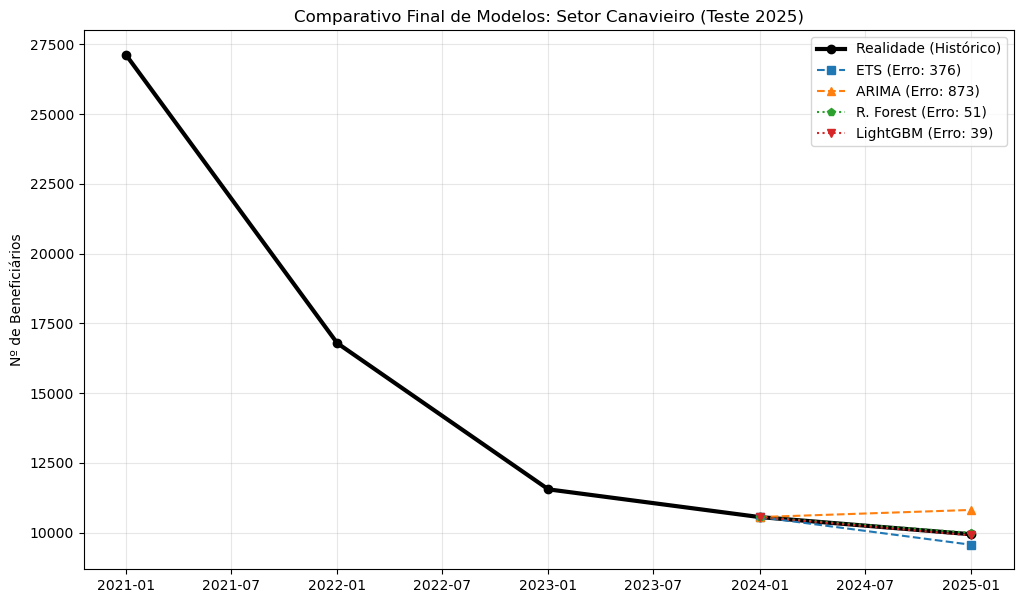

          Modelo  Previsão 2025    Erro %
0            ETS    9567.999886  3.781176
1          ARIMA   10816.650942  8.775653
2  Random Forest    9994.825024  0.511112
3       LightGBM    9905.045620  0.391738


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')

# 1. Carregamento e Preparação
file_path = r'C:\Users\kaila\Documents\TCC\data\cientista_cp.xlsx'
df = pd.read_excel(file_path, engine='openpyxl')

# Limpeza básica
df['beneficiarios'] = pd.to_numeric(df['beneficiarios'], errors='coerce').fillna(0)
df['ANO'] = df['ANO'].astype(int)

# --- PREPARAÇÃO PARA MODELOS ESTATÍSTICOS (Agregado) ---
series_cana = df[df['PROGRAMA'] == 'ZONA CANAVIEIRA'].groupby('ANO')['beneficiarios'].sum()
series_cana.index = pd.to_datetime(series_cana.index, format='%Y')
series_cana = series_cana.asfreq('YS')
train_stat = series_cana[:'2024-01-01']

# --- PREPARAÇÃO PARA MODELOS DE ML (Global/Pooled) ---
df_ml = df.sort_values(['MUNICIPIO', 'PROGRAMA', 'ANO'])
df_ml['lag_1'] = df_ml.groupby(['MUNICIPIO', 'PROGRAMA'])['beneficiarios'].shift(1)
df_ml = df_ml.dropna(subset=['lag_1']).copy()
le = LabelEncoder()
df_ml['PROG_CODE'] = le.fit_transform(df_ml['PROGRAMA'])

train_ml = df_ml[df_ml['ANO'] < 2025].copy()
test_ml = df_ml[df_ml['ANO'] == 2025].copy()
X_train, y_train = train_ml[['ANO', 'PROG_CODE', 'lag_1']], train_ml['beneficiarios']
X_test = test_ml[['ANO', 'PROG_CODE', 'lag_1']]

# 2. Treinamento dos 4 Modelos
# A. ETS (Holt Linear)
model_ets = ExponentialSmoothing(train_stat, trend='add', seasonal=None).fit()
pred_ets = model_ets.forecast(1).iloc[0]

# B. ARIMA (1,1,0)
model_arima = ARIMA(train_stat, order=(1, 1, 0)).fit()
pred_arima = model_arima.forecast(1).iloc[0]

# C. Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
test_ml['pred_RF'] = model_rf.predict(X_test)
pred_rf = test_ml[test_ml['PROGRAMA'] == 'ZONA CANAVIEIRA']['pred_RF'].sum()

# D. LightGBM
model_lgb = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1).fit(X_train, y_train)
test_ml['pred_LGBM'] = model_lgb.predict(X_test)
pred_lgbm = test_ml[test_ml['PROGRAMA'] == 'ZONA CANAVIEIRA']['pred_LGBM'].sum()

# 3. Plotagem de Comparação
plt.figure(figsize=(12, 7))

# Série Real
plt.plot(series_cana.index, series_cana.values, label='Realidade (Histórico)', color='black', linewidth=3, marker='o')

# Intervalo de Validação (2024 -> 2025)
x_val = [series_cana.index[-2], series_cana.index[-1]]
y_real_2024 = series_cana.values[-2]

plt.plot(x_val, [y_real_2024, pred_ets], label=f'ETS (Erro: {abs(pred_ets-series_cana.values[-1]):.0f})', linestyle='--', marker='s')
plt.plot(x_val, [y_real_2024, pred_arima], label=f'ARIMA (Erro: {abs(pred_arima-series_cana.values[-1]):.0f})', linestyle='--', marker='^')
plt.plot(x_val, [y_real_2024, pred_rf], label=f'R. Forest (Erro: {abs(pred_rf-series_cana.values[-1]):.0f})', linestyle=':', marker='p')
plt.plot(x_val, [y_real_2024, pred_lgbm], label=f'LightGBM (Erro: {abs(pred_lgbm-series_cana.values[-1]):.0f})', linestyle=':', marker='v')

plt.title('Comparativo Final de Modelos: Setor Canavieiro (Teste 2025)')
plt.ylabel('Nº de Beneficiários')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Tabela de Resultados
res_final = pd.DataFrame({
    'Modelo': ['ETS', 'ARIMA', 'Random Forest', 'LightGBM'],
    'Previsão 2025': [pred_ets, pred_arima, pred_rf, pred_lgbm],
    'Erro %': [abs(pred_ets-series_cana.values[-1])/series_cana.values[-1]*100,
               abs(pred_arima-series_cana.values[-1])/series_cana.values[-1]*100,
               abs(pred_rf-series_cana.values[-1])/series_cana.values[-1]*100,
               abs(pred_lgbm-series_cana.values[-1])/series_cana.values[-1]*100]
})
print(res_final)